# Coffee sales prediction

# Librerías

In [406]:
# Básicos
import pandas as pd
import sys
# graphics
import matplotlib.pyplot as plt
import seaborn as sns
# time series
from datetime import datetime
# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

print(f'Pandas version {pd.__version__}')
print(f'Python version {sys.version}')

Pandas version 2.3.2
Python version 3.10.13 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:15:57) [MSC v.1916 64 bit (AMD64)]


# Datos

In [407]:
df=pd.read_csv('data/index_1.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [408]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


# Preparación de los datos

In [409]:
# eliminamos # eliminamos datos nulos
df=df.dropna()

# convertimos las fechas
df['datetime']=pd.to_datetime(df['datetime'])
df['date']=pd.to_datetime(df['date'])
df.head()


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [ ]:
# separamos la fecha y hora
df['year']=df['datetime'].dt.year  
df['month']=df['datetime'].dt.month
df['day']=df['datetime'].dt.day
df['weekday']=df['datetime'].dt.weekday
df['hour']=df['datetime'].dt.hour

In [411]:
'''
    La columna 'cash_type' solo contiene un método de pago, por lo que podemos
    omitirla del análisis
'''
dummies=pd.get_dummies(df['coffee_name'], drop_first=True, dtype=int)
# juntamos las columnas codificadas con el df original
df=pd.concat([df,dummies], axis=1)

print(df.columns)

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'year',
       'month', 'day', 'weekday', 'hour', 'Americano with Milk', 'Cappuccino',
       'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte'],
      dtype='object')


In [412]:
# separamos las variables
X=df.drop(columns=['money', 'date', 'datetime', 'card', 'cash_type', 'coffee_name'])
y=df['money']

In [413]:
df.head()

,date,datetime,cash_type,card,money,coffee_name,year,month,day,weekday,hour,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024,3,1,4,10,0,0,0,0,0,0,1
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,3,1,4,12,0,0,0,0,0,1,0
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,3,1,4,12,0,0,0,0,0,1,0
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024,3,1,4,13,0,0,0,0,0,0,0
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024,3,1,4,13,0,0,0,0,0,0,1


In [414]:
X.head()

,year,month,day,weekday,hour,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024,3,1,4,10,0,0,0,0,0,0,1
1,2024,3,1,4,12,0,0,0,0,0,1,0
2,2024,3,1,4,12,0,0,0,0,0,1,0
3,2024,3,1,4,13,0,0,0,0,0,0,0
4,2024,3,1,4,13,0,0,0,0,0,0,1


In [415]:
y.head()

0    38.7
1    38.7
2    38.7
3    28.9
4    38.7
Name: money, dtype: float64

In [416]:
'''
    Dividimos el dataframe en partes iguales manteniendo el orden cronológico
'''
n=len(df)
# tomamos el 80 % de los datos
split_range=int(n*0.8)

X_train=X.iloc[:split_range]
X_test=X.iloc[split_range:]

y_train=y.iloc[:split_range]
y_test=y.iloc[split_range:]

# Análisis exploratorio

In [417]:
# seleccionamos la columna datetime como el índice
df=df.set_index('datetime')

In [418]:
# períodos útiles
summer_24=[datetime(2024,6,21), datetime(2024,9,22)]
winter_24=[datetime(2024,12,21), datetime(2025,3,20)]
winter_23=[datetime(2024,3,1), datetime(2024,3,20)]

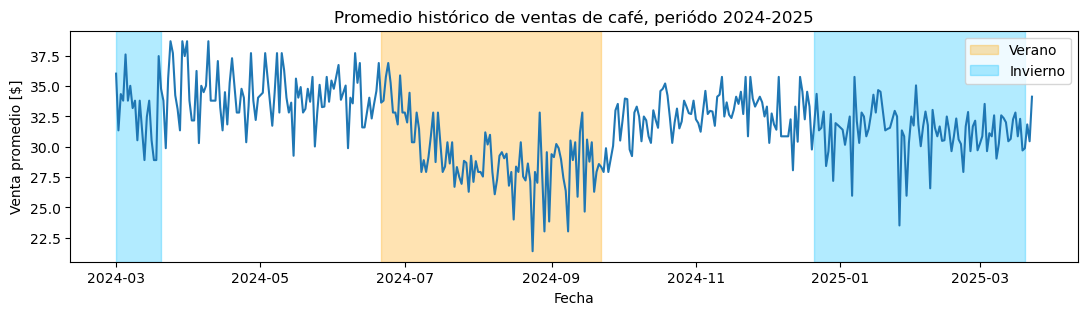

In [419]:
# promedio diario
daily_mean=df['money'].resample('D').mean().reset_index()
fig, ax=plt.subplots(figsize=(13,3))
sns.lineplot(data=daily_mean, x='datetime', y='money')
plt.title('Promedio histórico de ventas de café, periódo 2024-2025')
plt.xlabel('Fecha')
plt.ylabel('Venta promedio [$]')
ax.axvspan(summer_24[0],summer_24[1], alpha=0.3, color='orange', label='Verano')
ax.axvspan(winter_24[0], winter_24[1], alpha=0.3, color='deepskyblue', label='Invierno')
ax.axvspan(winter_23[0], winter_23[1], alpha=0.3, color='deepskyblue')
plt.legend()
plt.show()

In [420]:
max_sale=sales_per_day.iloc[
    sales_per_day['money'].idxmax()
].to_list()

min_sale=sales_per_day.iloc[sales_per_day['money'].idxmin()].to_list()

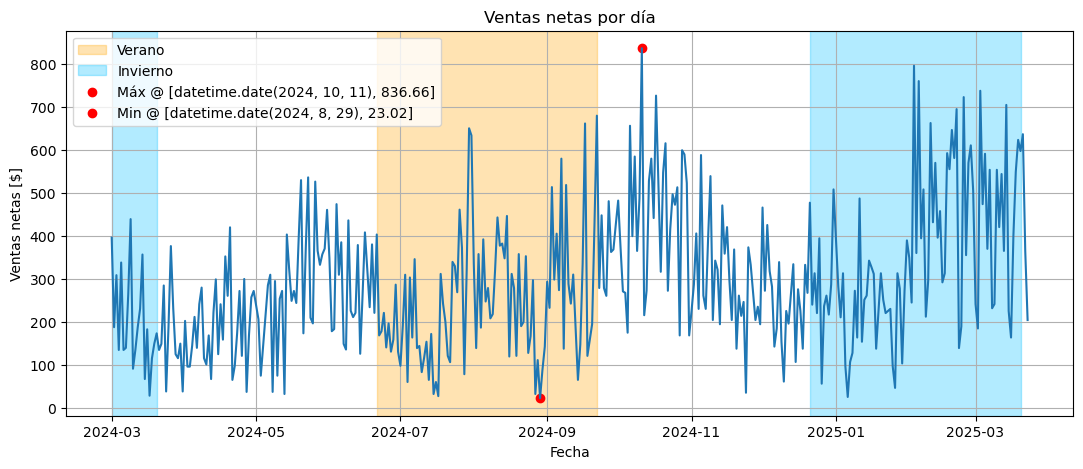

In [421]:
sales_per_day=df.groupby(df['date'].dt.date)['money'].sum().reset_index()
# máximos y mínimos globales
max_sale=sales_per_day.iloc[sales_per_day['money'].idxmax()].to_list()
min_sale=sales_per_day.iloc[sales_per_day['money'].idxmin()].to_list()
# ajustes de la gráfica
fig, ax=plt.subplots(figsize=(13, 5))
sns.lineplot(sales_per_day, x='date', y='money')
plt.title('Ventas netas por día')
plt.xlabel('Fecha')
plt.ylabel('Ventas netas [$]')

# anotaciones
ax.axvspan(summer_24[0],summer_24[1], alpha=0.3, color='orange', label='Verano')
ax.axvspan(winter_24[0], winter_24[1], alpha=0.3, color='deepskyblue', label='Invierno')
ax.axvspan(winter_23[0], winter_23[1], alpha=0.3, color='deepskyblue')
ax.scatter(max_sale[0], max_sale[1], color='red', label=f'Máx @ {max_sale}')
ax.scatter(min_sale[0], min_sale[1], color='red', label=f'Min @ {min_sale}')
plt.legend()
plt.grid(True)
plt.show()

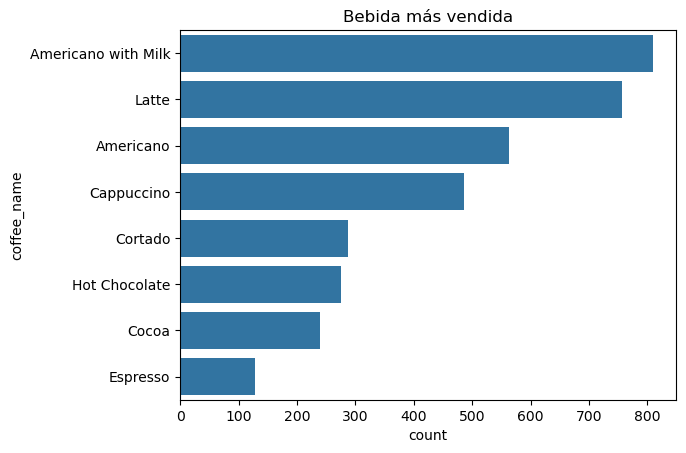

In [422]:
most_selled=df['coffee_name'].value_counts().reset_index()
sns.barplot(most_selled, y='coffee_name', x='count', orient='h')
plt.title('Bebida más vendida')
plt.show()

In [423]:
# agrupamos las ventas por mes
monthly_sales=(
    df
    .groupby(['month','year', 'coffee_name'], as_index=False)['money']
    .sum()
)
monthly_sales['date']=pd.to_datetime(
    dict(year=monthly_sales['year'], month=monthly_sales['month'], day=1)
)

monthly_sales

,month,year,coffee_name,money,date
0,1,2025,Americano,649.00,2025-01-01
1,1,2025,Americano with Milk,1604.72,2025-01-01
2,1,2025,Cappuccino,965.52,2025-01-01
3,1,2025,Cocoa,500.64,2025-01-01
4,1,2025,Cortado,571.12,2025-01-01
...,...,...,...,...,...
99,12,2024,Cocoa,750.96,2024-12-01
100,12,2024,Cortado,804.76,2024-12-01
101,12,2024,Espresso,252.72,2024-12-01
102,12,2024,Hot Chocolate,929.76,2024-12-01


In [424]:
top_per_month=monthly_sales.loc[monthly_sales.groupby(['year','month'])['money'].idxmax()]
top_per_month

,month,year,coffee_name,money,date
23,3,2024,Latte,1354.50,2024-03-01
34,4,2024,Cappuccino,1381.44,2024-04-01
42,5,2024,Cappuccino,1961.44,2024-05-01
49,6,2024,Americano with Milk,2166.12,2024-06-01
57,7,2024,Americano with Milk,1863.80,2024-07-01
65,8,2024,Americano with Milk,2010.24,2024-08-01
79,9,2024,Latte,3114.48,2024-09-01
87,10,2024,Latte,4291.20,2024-10-01
95,11,2024,Latte,2431.68,2024-11-01
97,12,2024,Americano with Milk,1759.02,2024-12-01


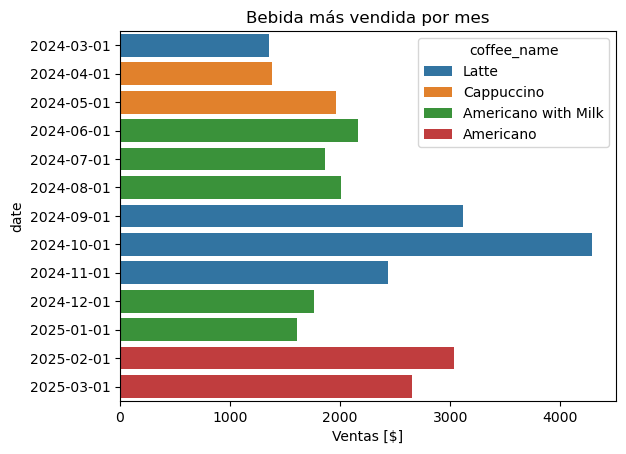

In [425]:
sns.barplot(
    data=top_per_month,
    y='date',
    x ='money',
    hue='coffee_name'
)
plt.title('Bebida más vendida por mes')
plt.xlabel('Ventas [$]')
plt.show()

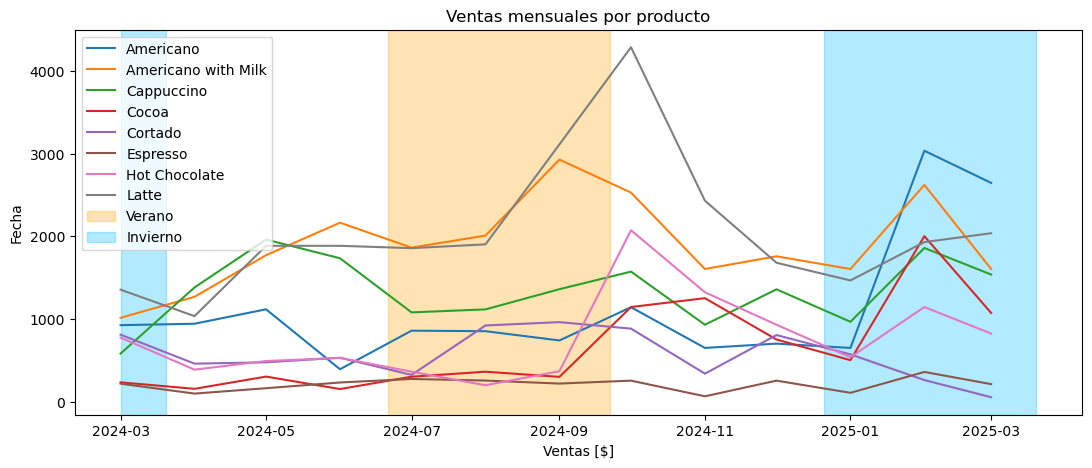

In [426]:
fig, ax=plt.subplots(figsize=(13,5))
sns.lineplot(
    data=monthly_sales,
    x='date',
    y='money',
    hue='coffee_name'
)

plt.xlabel('Ventas [$]')
plt.ylabel('Fecha')
plt.title('Ventas mensuales por producto')
# anotaciones
ax.axvspan(summer_24[0],summer_24[1], alpha=0.3, color='orange', label='Verano')
ax.axvspan(winter_24[0], winter_24[1], alpha=0.3, color='deepskyblue', label='Invierno')
ax.axvspan(winter_23[0], winter_23[1], alpha=0.3, color='deepskyblue')

plt.legend()
plt.show()

# Implementación del modelo

In [427]:
# modelo de regresión lineal simple
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [428]:
# usamos el promedio del error absoluto como métrica de desempeño
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)


MAE: 0.4843382234270464


In [429]:
X_test

,year,month,day,weekday,hour,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
2926,2025,2,3,0,15,0,0,0,0,0,0,0
2927,2025,2,3,0,17,0,0,1,0,0,0,0
2928,2025,2,3,0,17,1,0,0,0,0,0,0
2929,2025,2,3,0,17,1,0,0,0,0,0,0
2930,2025,2,3,0,17,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3631,2025,3,23,6,10,0,1,0,0,0,0,0
3632,2025,3,23,6,14,0,0,1,0,0,0,0
3633,2025,3,23,6,14,0,0,1,0,0,0,0
3634,2025,3,23,6,15,0,0,0,0,0,0,0


In [430]:
'''
    Agregamos a X_test una columna con la fecha en formato datetime
    y concatenamos y_test y preds para analizarlo
'''
X_test.reset_index()
X_test['datetime']=pd.to_datetime(X_test[['year', 'month', 'day', 'hour']])

X_test=pd.concat([X_test, y_test], axis=1)

X_test['preds']=preds
# seleccionamos el índice 
X_test=X_test.set_index('datetime').sort_index()
X_test.head()

C:\Users\Mi PC\AppData\Local\Temp\ipykernel_16472\3759891973.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['datetime']=pd.to_datetime(X_test[['year', 'month', 'day', 'hour']])


,year,month,day,weekday,hour,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte,money,preds
datetime,,,,,,,,,,,,,,
2025-02-03 15:00:00,2025,2,3,0,15,0,0,0,0,0,0,0,25.96,25.766776
2025-02-03 17:00:00,2025,2,3,0,17,0,0,1,0,0,0,0,35.76,35.992611
2025-02-03 17:00:00,2025,2,3,0,17,1,0,0,0,0,0,0,30.86,30.535545
2025-02-03 17:00:00,2025,2,3,0,17,1,0,0,0,0,0,0,30.86,30.535545
2025-02-03 17:00:00,2025,2,3,0,17,1,0,0,0,0,0,0,30.86,30.535545


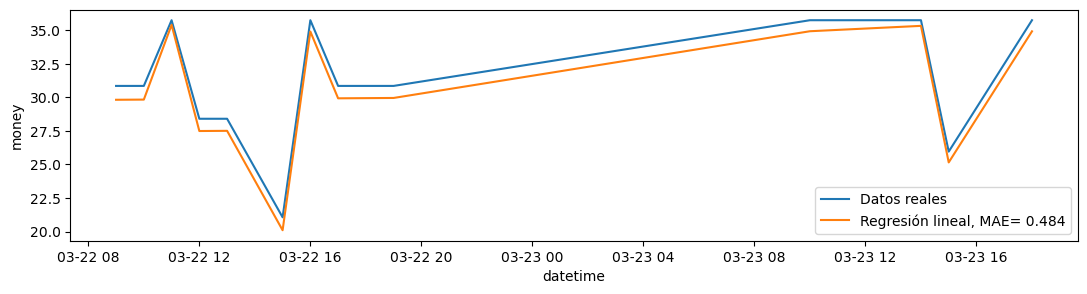

In [ ]:
march="2025-03-22"
fig, ax=plt.subplots(figsize=(13, 3))
sns.lineplot(
    data=X_test.loc[march:],
    x=X_test.loc[march:].index,
    y='money',
    errorbar=None,
    label="Datos reales"
)

sns.lineplot(
    data=X_test.loc[march:],
    x=X_test.loc[march:].index,
    y='preds',
    errorbar=None,
    label=f'Regresión lineal, MAE= {mae:.3f}'
)
plt.title("Comparación de ")
plt.ylabel("Venta [$]")
plt.xlabel("Fecha")
plt.legend()
plt.show()